# Authenticate with GCP

In [2]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_id = "olist-analytics-493621"
client = bigquery.Client(project=project_id)
print("BigQuery connected!")

Matplotlib is building the font cache; this may take a moment.


BigQuery connected!


# Pull data from BigQuery

In [3]:
df_customers = client.query("""
    SELECT * FROM `olist_analytics.mart_customer_orders`
""").to_dataframe()

df_rfm = client.query("""
    SELECT * FROM `olist_analytics.mart_rfm`
""").to_dataframe()

df_revenue = client.query("""
    SELECT * FROM `olist_analytics.mart_revenue`
""").to_dataframe()

print(f"Customers: {len(df_customers):,} rows")
print(f"RFM:       {len(df_rfm):,} rows")
print(f"Revenue:   {len(df_revenue):,} rows")

/Users/maytilok/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Customers: 96,219 rows
RFM:       96,219 rows
Revenue:   11,672 rows


# Customer overview

In [5]:
print("=" * 40)
print("OLIST CUSTOMER OVERVIEW")
print("=" * 40)
print(f"Total unique customers:  {df_customers['customer_unique_id'].nunique():,}")
print(f"Total orders:            {df_customers['total_orders'].sum():,}")
print(f"Total revenue:           R${df_customers['total_spent'].sum():,.2f}")
print(f"Avg spend per customer:  R${df_customers['total_spent'].mean():,.2f}")
print(f"Avg orders per customer: {df_customers['total_orders'].mean():.2f}")

OLIST CUSTOMER OVERVIEW
Total unique customers:  96,096
Total orders:            99,441
Total revenue:           R$15,843,553.24
Avg spend per customer:  R$165.83
Avg orders per customer: 1.03


## Key Business Findings

| Metric | Value | Insight |
|--------|-------|---------|
| Unique customers | 96,096 | Strong acquisition |
| Total revenue | R$15.8M | Healthy baseline |
| Avg orders per customer | 1.03 | Retention crisis |
| Avg spend per customer | R$165.83 | Reasonable basket size |

### Core Problem
**97% of customers never place a second order.**
This project builds a customer intelligence platform to identify
at-risk customers and enable targeted retention campaigns.

# Revenue over time

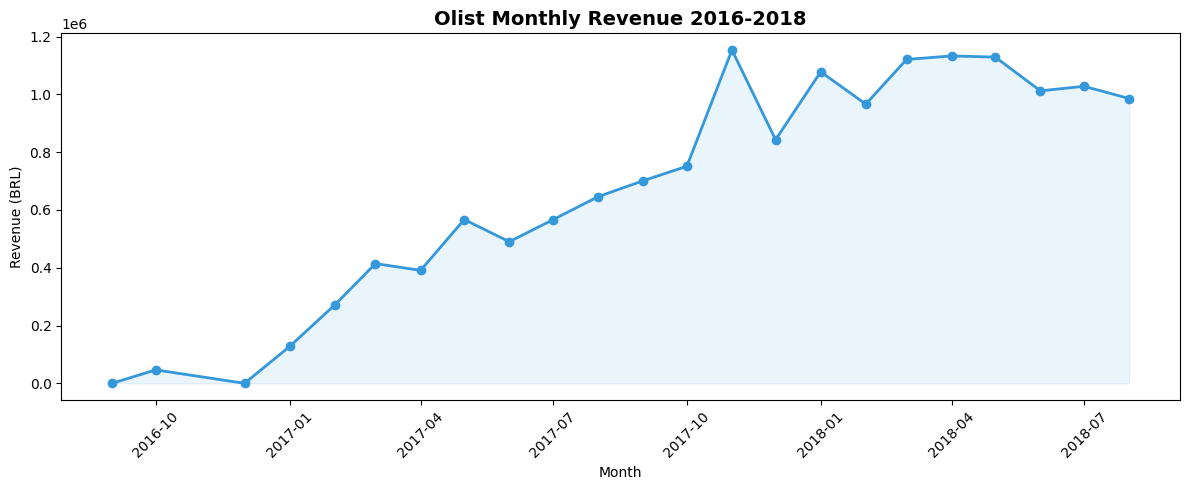

In [14]:
df_revenue['month'] = pd.to_datetime(df_revenue['month'])
monthly = df_revenue.groupby('month')['total_revenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['total_revenue'], 
         marker='o', linewidth=2, color='#3498db')
plt.fill_between(monthly['month'], monthly['total_revenue'], alpha=0.1, color='#3498db')
plt.title('Olist Monthly Revenue 2016-2018', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Customer segment distribution

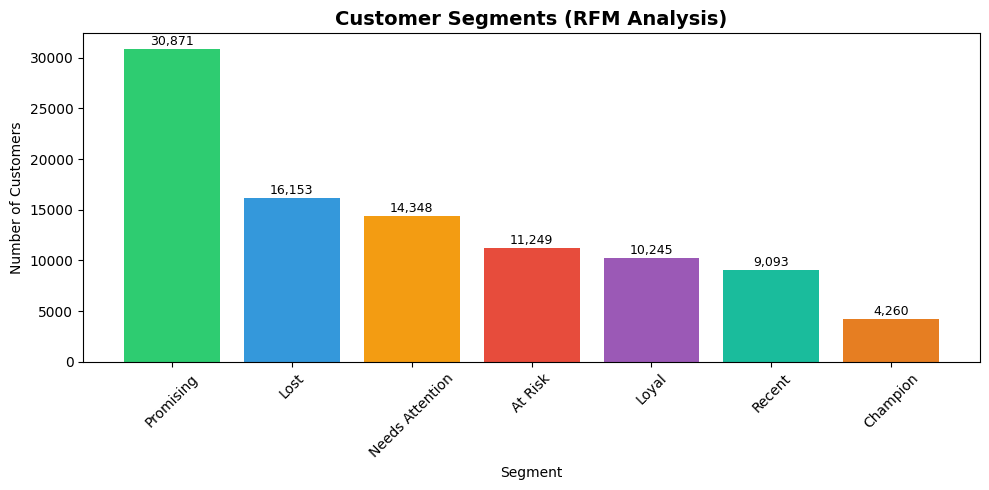


Segment breakdown:
  Promising            30,871 customers (32.1%)
  Lost                 16,153 customers (16.8%)
  Needs Attention      14,348 customers (14.9%)
  At Risk              11,249 customers (11.7%)
  Loyal                10,245 customers (10.6%)
  Recent                9,093 customers (9.5%)
  Champion              4,260 customers (4.4%)


In [15]:
segment_counts = df_rfm['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'count']

colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6','#1abc9c','#e67e22']

plt.figure(figsize=(10, 5))
bars = plt.bar(segment_counts['segment'], segment_counts['count'], color=colors)
plt.title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

for bar, count in zip(bars, segment_counts['count']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../dashboard/segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSegment breakdown:")
for _, row in segment_counts.iterrows():
    pct = row['count'] / len(df_rfm) * 100
    print(f"  {row['segment']:<20} {row['count']:>6,} customers ({pct:.1f}%)")

# Top product categories

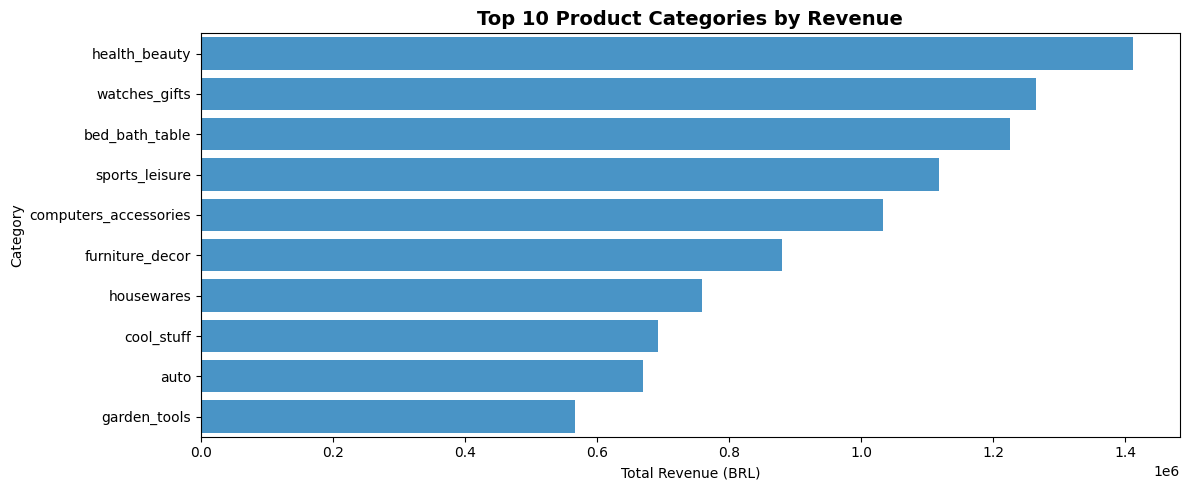

In [16]:
top_categories = (
    df_revenue.groupby('product_category')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_categories, x='total_revenue', 
            y='product_category', color='#3498db')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../dashboard/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Top states by revenue

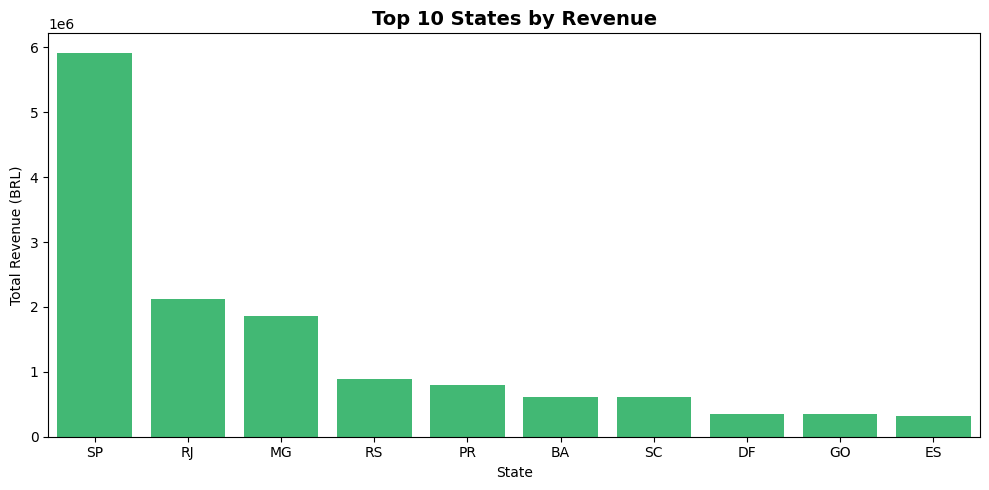

In [17]:
top_states = (
    df_customers.groupby('customer_state')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_states, x='customer_state', 
            y='total_spent', color='#2ecc71')
plt.title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('../dashboard/top_states.png', dpi=150, bbox_inches='tight')
plt.show()